# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Lita Rahma Sadina
- **Email:** litarahmasadina@gmail.com
- **ID Dicoding:** CDCC002D6X1264

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Pada musim dan kategori kondisi cuaca seperti apa sehingga rata-rata penyewaan sepeda mencapai angka tertinggi dan terendah selama periode tahun 2011-2012?
- Pertanyaan 2: Pada jam berapa terjadi puncak (rata-rata tertinggi) penyewaan sepeda dan bagaimana perbedaannya selama hari kerja dan hari libur pada periode tahun 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [29]:
# Memuat data day.csv
day_df = pd.read_csv("day.csv")

# Memuat data hour.csv
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari tabel hour untuk memastikan data berhasil dimuat
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset berupa day.csv dan hour.csv berhasil dimuat dengan bukti dapat ditampilkan menggunakan .head().
- Kedua tabel memiliki struktur data yang serupa seperti kondisi cuaca, waktu, dan musim.

### Assessing Data

In [20]:
# Mengecek tipe data dan missing value
print("Info Data day.csv")
day_df.info()
print("Info Data hour.csv")
hour_df.info()

# Mengecek duplikasi data
print("Jumlah duplikasi day_df: ", day_df.duplicated().sum())
print("Jumlah duplikasi hour_df: ", hour_df.duplicated().sum())

Info Data day.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
Info Data hour.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 

**Insight:**
- Tidak terdapat missing value maupun duplikasi data pada kedua dataset yang dimuat.
- Tipe data untuk kolom dteday terbaca sebagai object bukan waktu/tanggal.

### Cleaning Data

In [30]:
# Mengubah nama kolom agar lebih mudah dibaca
day_df.rename(columns={'dteday': 'date', 'yr': 'year', 'mnth': 'month', 'weathersit': 'weather_condition', 'cnt': 'total_count'}, inplace=True)
hour_df.rename(columns={'dteday': 'date', 'yr': 'year', 'mnth': 'month', 'hr': 'hour', 'weathersit': 'weather_condition', 'cnt': 'total_count'}, inplace=True)

# Mengubah tipe data kolom 'dteday' dari object (string) menjadi datetime
day_df['date'] = pd.to_datetime(day_df['date'])
hour_df['date'] = pd.to_datetime(hour_df['date'])

# Mengubah nilai angka menjadi teks pada kolom 'season'
day_df['season'] = day_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# Mengubah nilai angka menjadi teks pada kolom 'weather_condition' (Sudah disesuaikan)
day_df['weather_condition'] = day_df['weather_condition'].map({
    1: 'Cerah', 2: 'Berkabut', 3: 'Hujan/Salju Ringan', 4: 'Cuaca Buruk'
})

# Menampilkan 5 baris pertama dari tabel hour untuk memastikan data berhasil dimuat
day_df.head()

,instant,date,season,year,month,holiday,weekday,workingday,weather_condition,temp,atemp,hum,windspeed,casual,registered,total_count
0,1,2011-01-01,Spring,0,1,0,6,0,Berkabut,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Berkabut,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Cerah,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Cerah,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Cerah,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Tipe data untuk kolom dteday berhasil dirumah menjadi datetime.
- Beberapa nama kolom dirubah untuk mempermudah membaca data.

## Exploratory Data Analysis (EDA)

### Explore Dataset (day & hour)

In [22]:
# Eksplorasi penyewaan sepeda berdasarkan Musim (Season)
print("Penyewaan Sepeda berdasarkan Musim")
display(day_df.groupby("season").agg({
    "total_count": ["max", "min", "mean", "sum"]
}))

# Eksplorasi penyewaan sepeda berdasarkan Kondisi Cuaca
print("Penyewaan Sepeda berdasarkan Kondisi Cuaca")
display(day_df.groupby("weather_condition").agg({
    "total_count": ["max", "min", "mean", "sum"]
}))

# Eksplorasi tren jam sibuk (Rata-rata penyewaan per jam)
print("5 Jam Paling Ramai untuk Penyewaan Sepeda")
display(hour_df.groupby("hour").agg({
    "total_count": "mean"
}).sort_values("total_count", ascending=False).head(5))

# Eksplorasi perbandingan rata-rata penyewaan per jam (Hari Kerja dengan Hari Libur)
print("Perbandingan Rata-rata Penyewaan Sepeda per Jam ")
print("Notes : 0 = Hari Libur, 1 = Hari Kerja")

tabel_perbandingan = hour_df.pivot_table(
    index="hour",
    columns="workingday",
    values="total_count",
    aggfunc="mean"
)
display(tabel_perbandingan)

Penyewaan Sepeda berdasarkan Musim


total_count                            
               max   min         mean      sum
season                                        
Fall          8714  1115  5644.303191  1061129
Spring        7836   431  2604.132597   471348
Summer        8362   795  4992.331522   918589
Winter        8555    22  4728.162921   841613

Penyewaan Sepeda berdasarkan Kondisi Cuaca


total_count                           
                           max  min         mean      sum
weather_condition                                        
Berkabut                  8362  605  4035.862348   996858
Cerah                     8714  431  4876.786177  2257952
Hujan/Salju Ringan        4639   22  1803.285714    37869

5 Jam Paling Ramai untuk Penyewaan Sepeda


,total_count
hour,
17,461.452055
18,425.510989
8,359.011004
16,311.983562
19,311.523352


Perbandingan Rata-rata Penyewaan Sepeda per Jam 
Notes : 0 = Hari Libur, 1 = Hari Kerja


workingday,0,1
hour,,
0,90.800000,36.786290
1,69.508696,16.552632
2,53.171053,8.683778
3,25.775330,4.942553
4,8.264317,5.429787
5,8.689189,24.913131
6,18.742358,102.500000
7,43.406926,290.612903
8,105.653680,477.006048


**Insight:**
- Dari dataset day_df, rata-rata penyewaan paling tinggi berada di musim gugur dan paling paling rendah berada di musim panas.
- Dari dataset day_df, rata-rata penyewaan paling tinggi yaitu saat cuaca sedang cerah/berawan dan paling rendah saat cuaca sedang hujan/salju ringan.
- Dataset untuk kondisi cuaca kategori 4 tidak ada karena cuaca dengan kategori tersebut tidak pernah berlangsung selama 24 jam.
- Dari dataset hour_df, jam paling ramai orang-orang menyewa sepeda adalah pukul 17.
- Dari dataset hour_df, pada hari kerja penyewaan sepeda melonjak pada pukul 8 serta 17-18. Pada hari libur, penyewaan sepeda melonjak pada pukul 12-15.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada musim dan kategori kondisi cuaca seperti apa sehingga rata-rata penyewaan sepeda mencapai angka tertinggi dan terendah selama periode tahun 2011-2012?

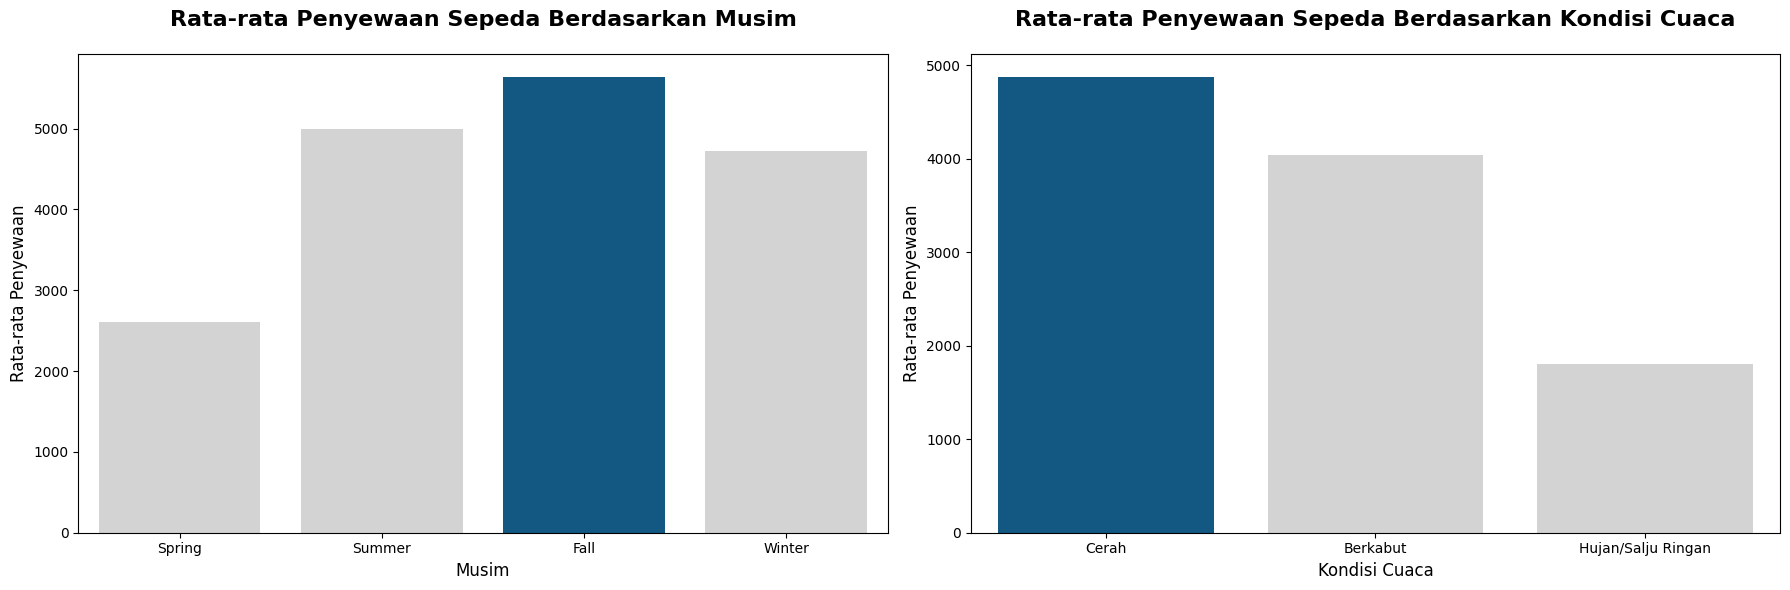

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# GRAFIK 1: Pengaruh Musim
colors_season_dict = {'Spring': '#D3D3D3', 'Summer': '#D3D3D3', 'Fall': '#005b96', 'Winter': '#D3D3D3'}
order_season = ['Spring', 'Summer', 'Fall', 'Winter']

sns.barplot(
    x='season',
    y='total_count',
    data=day_df,
    palette=colors_season_dict,
    hue='season',
    order=order_season,
    legend=False,
    errorbar=None,
    ax=ax[0]
)

ax[0].set_title('Rata-rata Penyewaan Sepeda Berdasarkan Musim', fontsize=16, fontweight='bold', pad=20)
ax[0].set_xlabel('Musim', fontsize=12)
ax[0].set_ylabel('Rata-rata Penyewaan', fontsize=12)

# GRAFIK 2: Pengaruh Cuaca
colors_weather_dict = {'Cerah': '#005b96', 'Berkabut': '#D3D3D3', 'Hujan/Salju Ringan': '#D3D3D3'}
order_weather = ['Cerah', 'Berkabut', 'Hujan/Salju Ringan']

sns.barplot(
    x='weather_condition',
    y='total_count',
    data=day_df,
    palette=colors_weather_dict,
    hue='weather_condition',
    order=order_weather,
    legend=False,
    errorbar=None,
    ax=ax[1]
)

ax[1].set_title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca', fontsize=16, fontweight='bold', pad=20)
ax[1].set_xlabel('Kondisi Cuaca', fontsize=12)
ax[1].set_ylabel('Rata-rata Penyewaan', fontsize=12)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Pada jam berapa terjadi puncak (rata-rata tertinggi) penyewaan sepeda dan bagaimana perbedaannya selama hari kerja dan hari libur pada periode tahun 2011-2012?

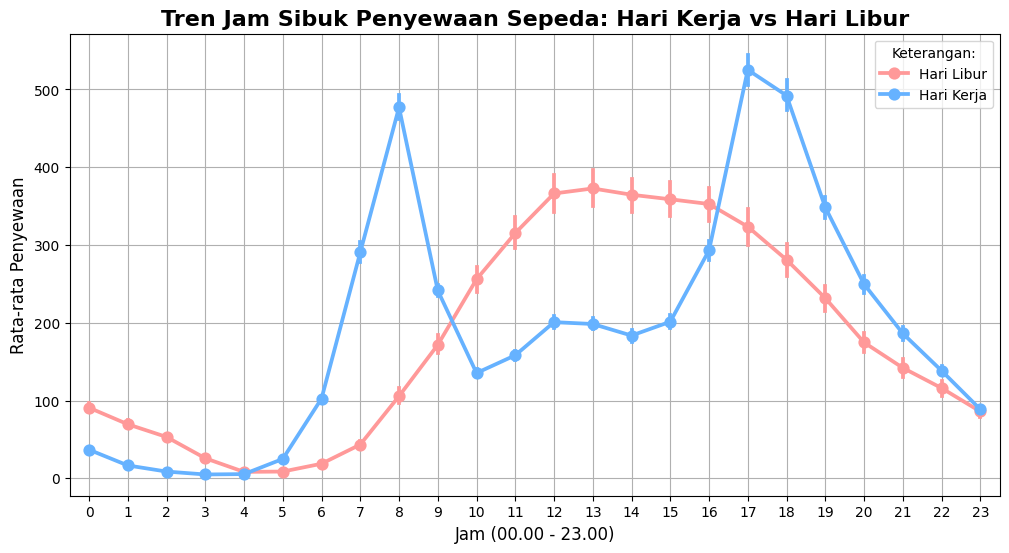

In [24]:
# Mengubah angka 0 dan 1 menjadi teks untuk keperluan grafik
hour_df['day_type'] = hour_df['workingday'].map({0: 'Hari Libur', 1: 'Hari Kerja'})

# Membuat line chart / point plot
plt.figure(figsize=(12, 6))
sns.pointplot(
    x='hour',
    y='total_count',
    hue='day_type',
    data=hour_df,
    palette=['#FF9999', '#66B2FF']
)

plt.title('Tren Jam Sibuk Penyewaan Sepeda: Hari Kerja vs Hari Libur', fontsize=16, fontweight='bold')
plt.xlabel('Jam (00.00 - 23.00)', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.legend(title='Keterangan:')
plt.grid(True)
plt.show()

**Insight:**
- Visualisasi data dalam bentuk diagram batang untuk pertanyaan 1 mempermudah pembaca dalam menerima informasi sehingga dapat terlihat dengan jelas bagaimana pengaruh musim dan cuaca terhadap penyewaan sepeda.
- Visualisasi data dalam bentuk *linechart* atau *pointplot* untuk pertanyaan 2 mempermudah pembaca dalam menerima informasi sehingga dapat terlihat perbandingan secara jelas jam mana saja yang paling sibuk/ramai penyewaan sepeda dan perbedaannya berdasarkan hari libur dan kerja.

## Analisis Lanjutan (Opsional)

In [25]:
# Analisis Lanjutan : Clustering (binning)
# Mengelompokkan jam menjadi kategori waktu (Manual Grouping)
def categorize_time(hour):
    if 5 <= hour < 12:
        return 'Pagi'
    elif 12 <= hour < 17:
        return 'Siang'
    elif 17 <= hour < 21:
        return 'Sore'
    else:
        return 'Malam'

# Membuat kolom baru bernama 'time_category'
hour_df['time_category'] = hour_df['hour'].apply(categorize_time)

# Mengevaluasi rata-rata penyewaan berdasarkan kategori waktu
print("Rata-rata Penyewaan Berdasarkan Kategori Waktu")
display(hour_df.groupby('time_category').agg({
    'total_count': 'mean'
}).sort_values('total_count', ascending=False))

Rata-rata Penyewaan Berdasarkan Kategori Waktu


,total_count
time_category,
Sore,356.201441
Siang,262.244719
Pagi,181.520583
Malam,65.687968


**Insight:**
- Dari analisis lanjutan, berdasarkan rata-rata penyewaan sepeda pada hari kerja dan libur paling tinggi terjadi pada sore hari dan paling rendah berada pada malam hari.

## Conclusion

- Conclution pertanyaan 1\
Melalui proses analisis data pada dataset Bike Sharing selama periode 2011-2012, terlihat bahwa banyak orang melakukan penyewaan sepeda pada musim gugur dan berdasarkan cuaca orang-orang cenderung menyewa pada cuaca cerah dan memiliki minat paling sedikit saat musim panas dan cuaca hujan/salju ringan. Sehingga pengaruh musim dan cuaca pada jumlah total penyewaan bergantung pada seberapa baik cuaca dan musim yang sedang terjadi dimana pada hasil dataset ini cuaca dan musim yang paling digemari berada pada cuaca cerah (tidak khawatir terkena hujan, memberikan pengalaman menjelajahi pemandangan sekitar secara langsung dengan mata, dan meningkatkan stamina tubuh) dan musim gugur (memiliki suhu udara paling pas, sejuk akibat adanya sedikit angin yang berhembus, dan tidak terlalu sering hujan).\
Karena banyaknya penyewaan sepeda sangat bergantung pada cuaca dan musim ideal, perusahaan perlu memastika ketersediaan sepeda mencapai makimal pada musim gugur dan cuaca cerah. Pada saat cuaca dan musing kurang ideal, perusahaan dapat memberikan promo/diskon khusus yang berada pada saat keadaan tersebut terjadi atau dapat juga melakukan *maintenance* sepeda yang disewakan.

- Conclution pertanyaan 2\
Melalui proses analisis data pada dataset Bike Sharing selama periode tahun 2011-2012, urutan jam yang menjadi puncak penyewaan sepeda berdasarkan rata-rata antara hari kerja dan hari liburadalah pada pukul 17.00 - 18.00, 08.00, 16.00, dan 19.00. Tren pada hari kerja yaitu memberikan lonjakan tajam pada pukul 08.00 yang merupakan waktu untuk berangkat kerja maupun sekolah dan pada pukul 17.00-18.00 yang merupakan waktu untuk pulang kerja maupun sekolah. Tren pada hari libur memberikan keramaian puncak pada pukul 12.00-15.00 yang umumnya menyewa sepeda untuk alasan bersantai.\
Perusahaan sebaiknya menerapkan strategi penyewaan sepeda bergantung pada situasi dan kondisinya. Pada hari kerja, sebaiknya stok sepeda pada lokasi strategis (seperti area pemukiman, perkantoran, dan sekolah) maksimal terutama pada jam-jam paling ramai penyewaan terjadi. Sedangkan pada hari libur, stok sepeda lebih baik disebar pada area rekreasi dari siang hari secara maksimal.